<a href="https://colab.research.google.com/github/lassenilssonnn/digital-legal-studies-python/blob/main/notebooks/Notebook_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Welcome to Lesson 8 of digital legal studies!

#Submitting Notebooks

Remember, you need to submit these notebooks, which you do through moodle.
Steps:

1. Access the notebook on Moodle ✅
2. Complete the exercises in the notebook (you have time for this in class)
3. Save the notebook under file, print, save as PDF (which you can choose under destination, if it isn't the default). Save it with your name.
4. Upload it to moodle as a PDF under the correct notebook name.



## Machine Learning


Machine learning is a way of using data to make predictions.

Instead of writing explicit rules (“if X happens, then do Y”), we give a model examples and let it learn patterns on its own.

In this notebook, we are doing something very simple:

We are asking:
**Can we predict an outcome based on a few variables?**

For example:

* Can we predict whether a country has high human rights?
* Can we predict whether a person will reoffend?

The basic idea is always the same:

We have **inputs (X)** — the information we give the model
We have an **output (y)** — what we want to predict

The model looks at the relationship between X and y in the data, and tries to learn a pattern.

Once it has learned this pattern, we can give it new data and ask:
**What do you predict now?**

### Important distinction

Machine learning is about **prediction**, not necessarily about **understanding**.

A model can:

* make accurate predictions
* without knowing why something happens
* and without identifying causal relationships

This is a key limitation, especially in law, politics, and social science.


### Why this matters

Machine learning is already used in:

* criminal justice (risk assessment tools)
* finance (credit scoring)
* hiring systems
* content moderation

So the real question is not just:
**“Does it work?”**

But:

* What is it actually learning?
* What assumptions are built into the data?
* Who might it fail for?

These are the questions we will start exploring in this lesson.


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CIRIGHTS data from Google Sheets
file_id = "1G272azBdZGuOb3hC50eWXMlf0_peSw8c"
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx"

df = pd.read_excel(url)

# Keep only 2017
cirights = df[df["year"] == 2017].copy()

print("Rows:", cirights.shape[0])
cirights.head()

Rows: 195


,country,year,ciri,cow,polity,unctry,unreg,unsubreg,Overall Human Rights Score,Physical Integrity Rights Index,...,Women's Social Rights Laws,Union Laws,Collective Bargaining Laws,Legal Limitations on Work Hours,Forced Labor Laws,Child Labor Laws,Minimum Wage Laws,Occupational Safety and Health Laws,Human Trafficking Laws,Fair Trial Laws
36,Afghanistan,2017,101,700.0,700.0,4.0,142.0,62.0,17.333334,2.0,...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,2.0,1.0
78,Albania,2017,104,339.0,339.0,8.0,150.0,39.0,52.000000,7.0,...,3.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,3.0
120,Algeria,2017,107,615.0,615.0,12.0,2.0,15.0,44.666668,6.0,...,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,2.0
162,Andorra,2017,110,232.0,232.0,20.0,150.0,39.0,82.666664,8.0,...,3.0,1.0,0.0,2.0,2.0,2.0,1.0,2.0,2.0,3.0
204,Angola,2017,113,540.0,540.0,17.0,2.0,17.0,40.000000,3.0,...,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0


In [ ]:
print(cirights.columns) ## we check the columns

Index(['country', 'year', 'ciri', 'cow', 'polity', 'unctry', 'unreg',
       'unsubreg', 'Overall Human Rights Score',
       'Physical Integrity Rights Index', 'Repression Index',
       'Civil and Political Rights Index', 'Worker Rights Practice Index',
       'Worker Rights Law Index', 'Brutality-based Atrocity',
       'Atrocity Intensity', 'Disappearances', 'Extrajudicial Killings',
       'Political Imprisonment', 'Torture',
       'Freedom of Assembly and Association', 'Freedom of Foreign Movement',
       'Freedom of Domestic Movement', 'Freedom of Speech',
       'Electoral Self-determination', 'Religious Freedom', 'Union Rights',
       'Collective Bargaining', 'Limitations on Work Hours', 'Forced Labor',
       'Child Labor', 'Minimum Wage', 'Occupational Safety and Health',
       'Human Trafficking', 'Judicial Independence', 'Women's Economic Rights',
       'Women's Political Rights', 'Women's Social Rights',
       'Human Rights NGO Freedom', 'Right to a Fair Trial',
   

## WHAT ARE WE GONNA DO HERE?

We are building a very simple machine learning model.

The goal:

> Can we predict whether a country has high human rights or not?


We start by cleaning the data, and keeping only the columns we care about.

We turn a variable into a simple question:
* high rights (1)
* not high rights (0)


Define inputs (X) and output (y)
X = the information we give the model (speech, courts, laws)
y = what we want to predict


### Split the data

We divide the data into

* training data, which the models learns from
* test data, which we test the model on

Then we check the accuracy:

If accuracy is high, it means the model is good at prediction, not that it is fair or correct or that it understands causal relationships.


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Keep only the columns we need, then drop missing values
ml_data = cirights[[
    "Physical Integrity Rights Index",
    "Freedom of Speech",
    "Judicial Independence",
    "Fair Trial Laws",
]].dropna()

# Create a simple outcome: high vs low rights
ml_data["high_rights"] = (ml_data["Physical Integrity Rights Index"] >= 6).astype(int)

# Features (inputs)
X = ml_data[[
    "Freedom of Speech",
    "Judicial Independence",
    "Fair Trial Laws",
]]

# Target (what we want to predict)
y = ml_data["high_rights"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Check accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8653846153846154



# EXERCISE:
# Try adding one more variable to X.
# For example: "Women's Economic Rights"
# Then re-run the model below and see if accuracy changes.

WHAT DID WE JUST DO — AND WHAT DOES 86% MEAN?

We built a simple model to answer one question:

Can we predict whether a country has high human rights or not?



STEP BY STEP (CONNECTED TO THE CODE)
1. Clean the data
```
ml_data = cirights[[...]].dropna()
```
We selected the columns we need and removed missing values.

Models cannot work with incomplete data, so we must clean it first.

2. Create the outcome (y)
```
ml_data["high_rights"] = (ml_data["Physical Integrity Rights Index"] >= 6).astype(int)
```
We turn a continuous variable (0–8) into a simple yes/no:

* 1 = high rights
* 0 = not high rights

This is what the model will try to predict.

3. Define inputs (X)
```
X = ml_data[[
    "Freedom of Speech",
    "Judicial Independence",
    "Fair Trial Laws"]]
```

These are the variables we give to the model.

Think:

What information does the model get to make its prediction?

4. Define the target (y)
```
y = ml_data["high_rights"]
```
This is the correct answer the model is trying to learn.

5. Split the data
```
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
```
We divide the data into:

*training data (70%) → model learns patterns
*test data (30%) → we check if it works
6. Train the model
```
model = LogisticRegression()
model.fit(X_train, y_train)
```

The model looks at the training data and learns patterns.

7. Check accuracy
```
model.score(X_test, y_test)
```

We test how often the model is correct on new (unseen) data.

WHAT DOES 86% ACCURACY MEAN?

It means:

> The model correctly predicts high vs low rights about 86% of the time.

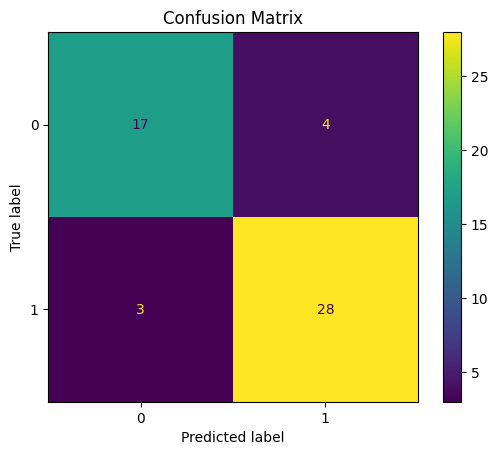

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

# EXERCISE:
# Look at the confusion matrix.
# Which type of mistake is more common?
# - Predicting high rights when it is not (false positive)
# - Predicting low rights when it is high (false negative)

## WHAT IS THIS SHOWING?

This compares:

- the real values
- the model's predictions

The diagonal boxes are correct predictions.  
The other boxes are mistakes.

So this gives us a more concrete picture than just one accuracy number.

If the model has high accuracy, we should see many cases on the diagonal.

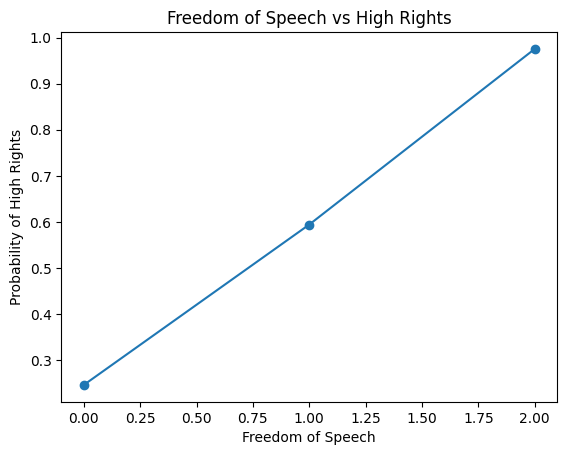

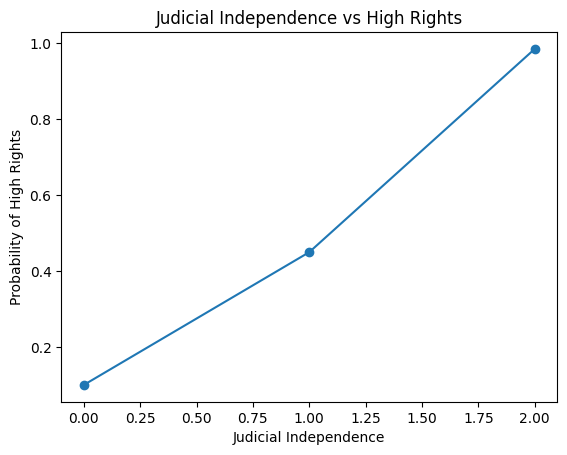

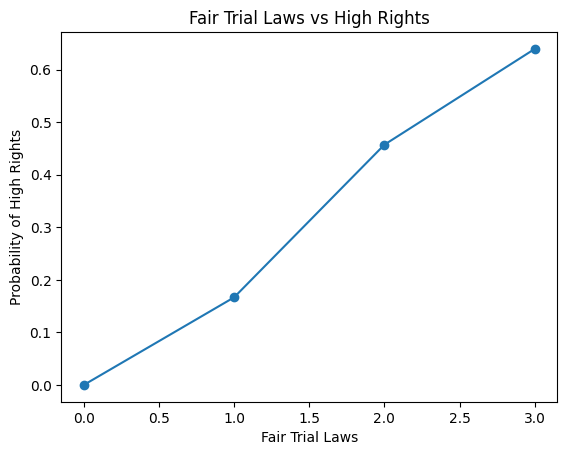

In [ ]:
for col in ["Freedom of Speech", "Judicial Independence", "Fair Trial Laws"]:
    ml_data.groupby(col)["high_rights"].mean().plot(marker="o")
    plt.title(f"{col} vs High Rights")
    plt.ylabel("Probability of High Rights")
    plt.show()

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Get predictions from the model
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred})

comparison.head()

,Actual,Predicted
0,0,1
1,0,0
2,0,1
3,1,1
4,0,0


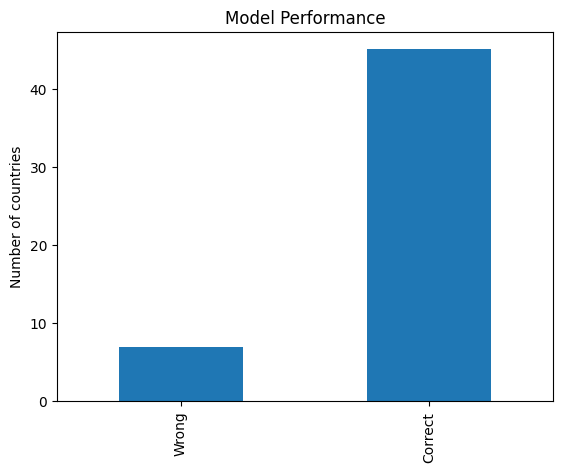

In [ ]:
comparison["Correct"] = comparison["Actual"] == comparison["Predicted"]

performance = comparison["Correct"].value_counts().sort_index()
performance.index = ["Wrong", "Correct"]

performance.plot(kind="bar")

plt.title("Model Performance")
plt.ylabel("Number of countries")
plt.show()

## COMPAS

In [ ]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
compas = pd.read_csv(url)

compas.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [ ]:
compas.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

In [ ]:
## Let's keep it simple

compas_simple = compas[[
    "age",
    "priors_count",
    "two_year_recid"
]].dropna()

In [ ]:
compas_simple["two_year_recid"].value_counts()

,count
two_year_recid,
0,3963
1,3251


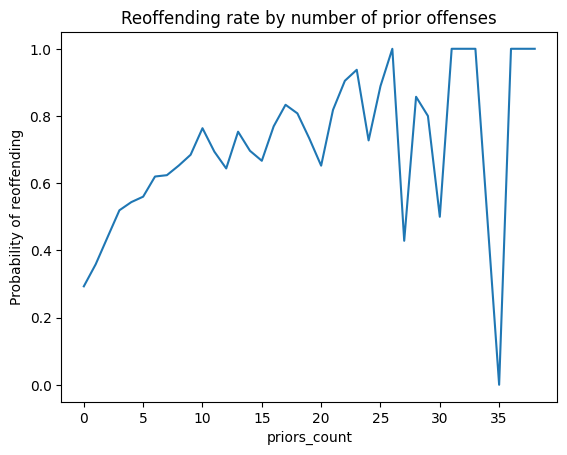

In [ ]:
compas_simple.groupby("priors_count")["two_year_recid"].mean().plot()

plt.title("Reoffending rate by number of prior offenses")
plt.ylabel("Probability of reoffending")
plt.show()

## TEACHING THE MODEL

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = compas_simple[["age", "priors_count"]]
y = compas_simple["two_year_recid"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6854503464203233


In [ ]:
compas_simple["two_year_recid"].value_counts(normalize=True)

,proportion
two_year_recid,
0,0.549348
1,0.450652


## EXPANDED COMPAS


compas_more = compas[[
    "age",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "two_year_recid"
]].dropna()

In [ ]:
compas_more = compas[[
    "age",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "two_year_recid"
]].dropna()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = compas_more.drop(columns=["two_year_recid"])
y = compas_more["two_year_recid"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6933025404157044


## Let's add sensitive information



In [ ]:
compas_richer = compas[[
    "age",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "race",
    "two_year_recid"
]].dropna()

In [ ]:
compas_richer = pd.get_dummies(compas_richer, columns=["race"])

In [ ]:
compas_richer.head(2)

,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,two_year_recid,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other
0,69,0,0,0,0,0,False,False,False,False,False,True
1,34,0,0,0,0,1,True,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Features (everything except target)
X = compas_richer.drop(columns=["two_year_recid"])

# Target
y = compas_richer["two_year_recid"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6937644341801386


### Seeing if there are different error rates between races

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Put actual and predicted values into one table
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Recreate a readable race column from the dummy columns
race_cols = [col for col in X_test.columns if col.startswith("race_")]

comparison["Race"] = X_test[race_cols].idxmax(axis=1).str.replace("race_", "", regex=False).values

# Was the prediction correct?
comparison["Correct"] = comparison["Actual"] == comparison["Predicted"]

# Accuracy by race
comparison.groupby("Race")["Correct"].mean().sort_values()

,Correct
Race,
Asian,0.666667
Native American,0.666667
Other,0.677686
Caucasian,0.691892
African-American,0.695144
Hispanic,0.704918


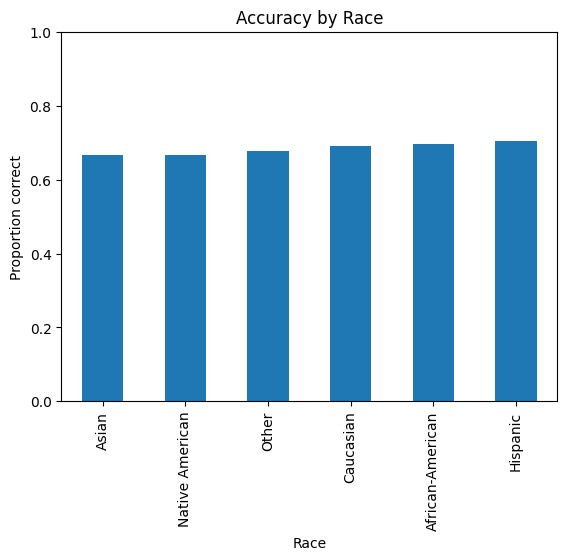

In [ ]:
comparison.groupby("Race")["Correct"].mean().sort_values().plot(kind="bar")

plt.title("Accuracy by Race")
plt.ylabel("Proportion correct")
plt.xlabel("Race")
plt.ylim(0, 1)
plt.show()

In [ ]:
comparison["Race"].value_counts()

,count
Race,
African-American,1112
Caucasian,740
Hispanic,183
Other,121
Asian,6
Native American,3


In [ ]:
## Data